In [1]:
# %pip install -e /home/darshan/A6/PCSAFT_cDFT/thermoift
import time
notebook_start = time.perf_counter()

import os
import json
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import seaborn as sns, shap
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from thermoift.rng_utils import get_rng
from thermoift import MLPostprocessing, plot_correlation_heatmap, print_model_metrics
import thermoift.PLOT_SETTINGS as ps

PLOT_FOLDER = "XGBoost_OUTPUTS"

In [2]:
df = pd.read_csv("../interfacial_results_dataset_A1.csv")

print(f"Total samples: {len(df)}")
print(f"\ngamma statistics:")
print(df["gamma"].describe())

Total samples: 19171

gamma statistics:
count    19171.000000
mean         9.172208
std          5.362102
min          0.501979
25%          4.384029
50%          8.788374
75%         13.688527
max         21.681737
Name: gamma, dtype: float64


In [3]:
target     = "gamma"
SEED       = 455552
rng        = get_rng(seed=SEED)

z_columns  = [col for col in df.columns if col.startswith("z_")]
Z_non_zero = [col for col in z_columns if (df[col] != 0).any()]
features   = ["temperature", "pressure"] + Z_non_zero

print(f"Selected features: {features}")

X = df[features]
y = df[target]

# 70/15/15 split: first 70/30, then split 30 into 15/15
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=SEED)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED)

print(f"\nTraining samples:   {X_train.shape[0]}")
print(f"Testing samples:    {X_test.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")

Selected features: ['temperature', 'pressure', 'z_carbon dioxide', 'z_hydrogen', 'z_nitrogen', 'z_argon', 'z_methane', 'z_oxygen', 'z_carbon monoxide', 'z_hydrogen sulfide']

Training samples:   13419
Testing samples:    2876
Validation samples: 2876


In [4]:
# XGBoost Regressor
xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=rng,
    n_jobs=-1)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_train_pred = xgb_model.predict(X_train)
y_test_pred  = xgb_model.predict(X_test)
y_val_pred   = xgb_model.predict(X_val)

# Metrics
metrics = print_model_metrics(y_train, y_train_pred, y_test, y_test_pred, target, unit="mN/m", y_val=y_val, y_val_pred=y_val_pred)

Model Performance for gamma

Training Set:
  R²:   0.999902
  RMSE: 0.053114 mN/m
  MAE:  0.038662 mN/m

Test Set:
  R²:   0.999802
  RMSE: 0.075808 mN/m
  MAE:  0.053390 mN/m

Validation Set:
  R²:   0.999806
  RMSE: 0.074214 mN/m
  MAE:  0.051146 mN/m


In [5]:
# 5-fold cross-validation
cv_scores = cross_val_score(xgb_model, X, y, cv=5, scoring='r2')

print(f"Cross-Validation R² Scores: {cv_scores}")
print(f"Mean CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

Cross-Validation R² Scores: [0.99943628 0.99912976 0.99920431 0.99934628 0.99788832]
Mean CV R²: 0.9990 (+/- 0.0011)


In [6]:
# XGBoost Feature Importance
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=list(df[features].columns)
).sort_values(ascending=False)

print("\nXGBoost Feature Importance (gain):")
print(xgb_importance.to_string())


XGBoost Feature Importance (gain):
temperature           0.848271
pressure              0.114812
z_hydrogen            0.022568
z_carbon dioxide      0.003677
z_carbon monoxide     0.003333
z_nitrogen            0.002605
z_methane             0.001910
z_hydrogen sulfide    0.001685
z_argon               0.000881
z_oxygen              0.000257


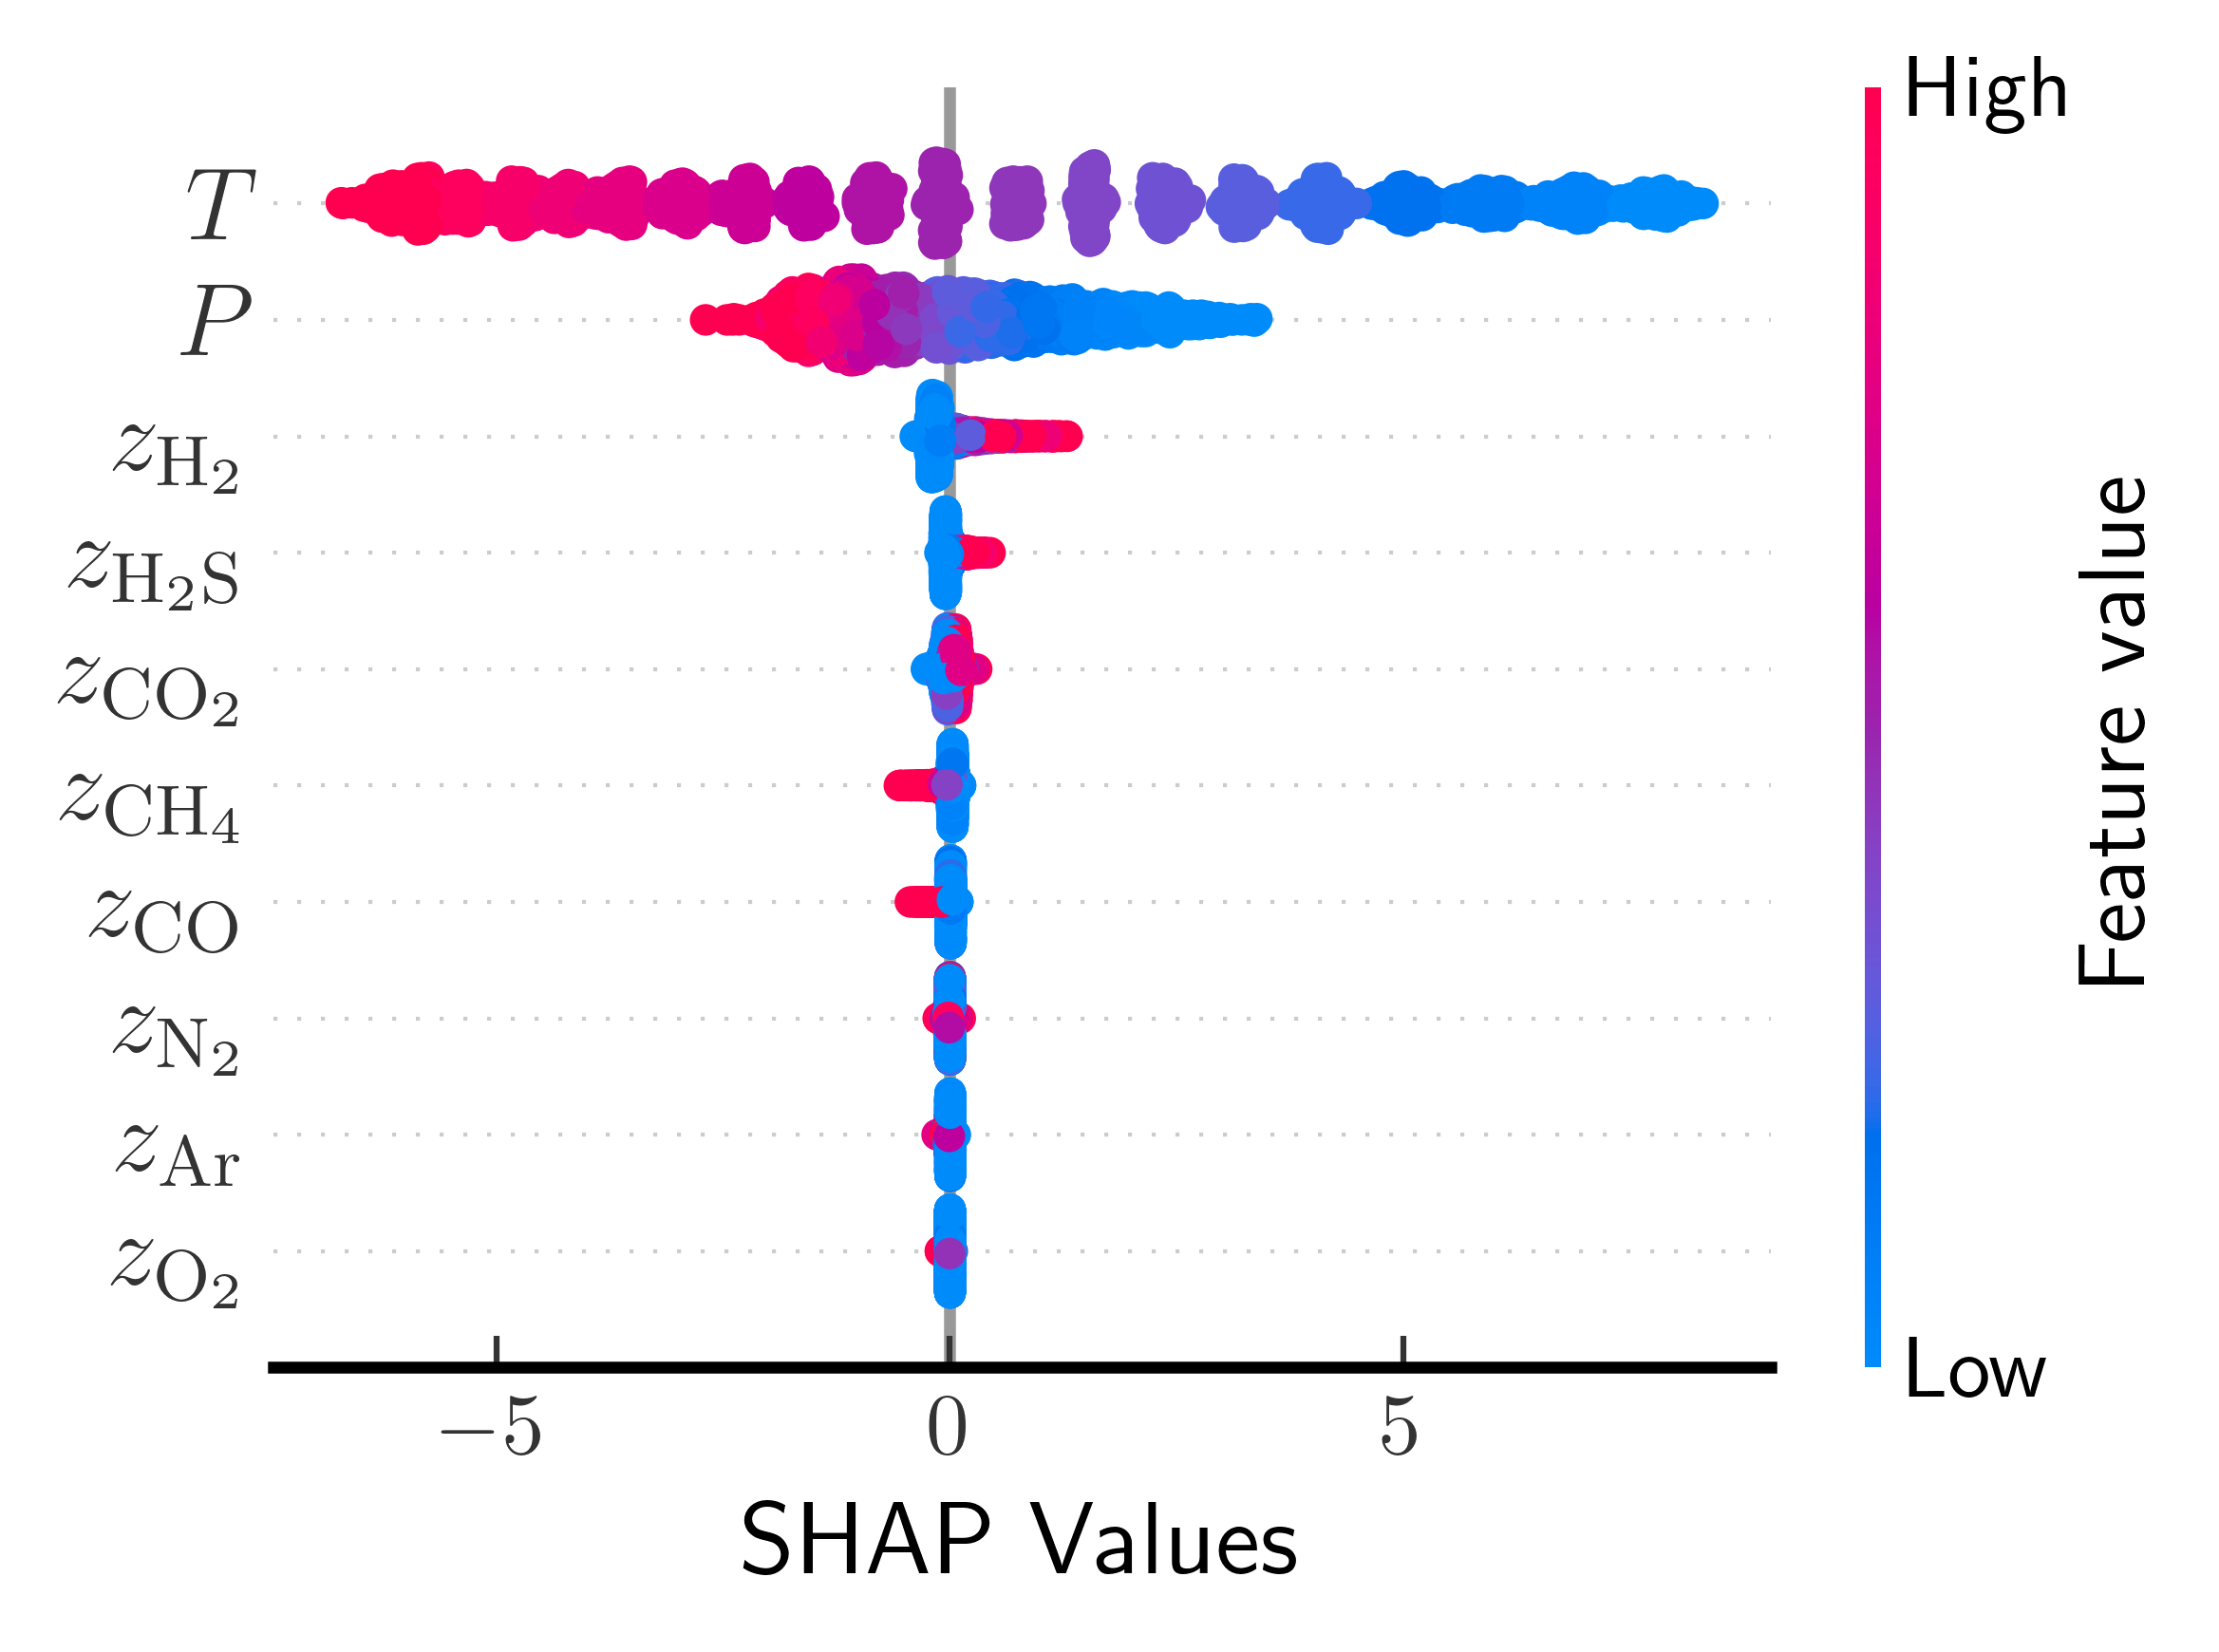

In [7]:
label_map = {
    "temperature": r"$T$",
    "pressure": r"$P$",
    "z_carbon dioxide": r"$z_{\mathrm{CO_2}}$",
    "z_hydrogen": r"$z_{\mathrm{H_2}}$",
    "z_argon": r"$z_{\mathrm{Ar}}$",
    "z_nitrogen": r"$z_{\mathrm{N_2}}$",
    "z_methane": r"$z_{\mathrm{CH_4}}$",
    "z_oxygen": r"$z_{\mathrm{O_2}}$",
    "z_carbon monoxide": r"$z_{\mathrm{CO}}$",
    "z_hydrogen sulfide": r"$z_{\mathrm{H_2S}}$",
    "gamma": r"$\gamma$",
}

# SHAP Values — XGBoost
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

feature_labels = [label_map.get(f, f) for f in features]
shap_df = pd.DataFrame(shap_values, columns=feature_labels)

# Plot 1: Beeswarm Summary
fig, ax = ps.plot_init()
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_labels,
    show=False,
    plot_size=None)
ax = plt.gca()
ax.set_xlabel("SHAP Values")
plt.tight_layout()
ps.save_plot(fig, "XGB_gamma_shap_summary")
plt.show()

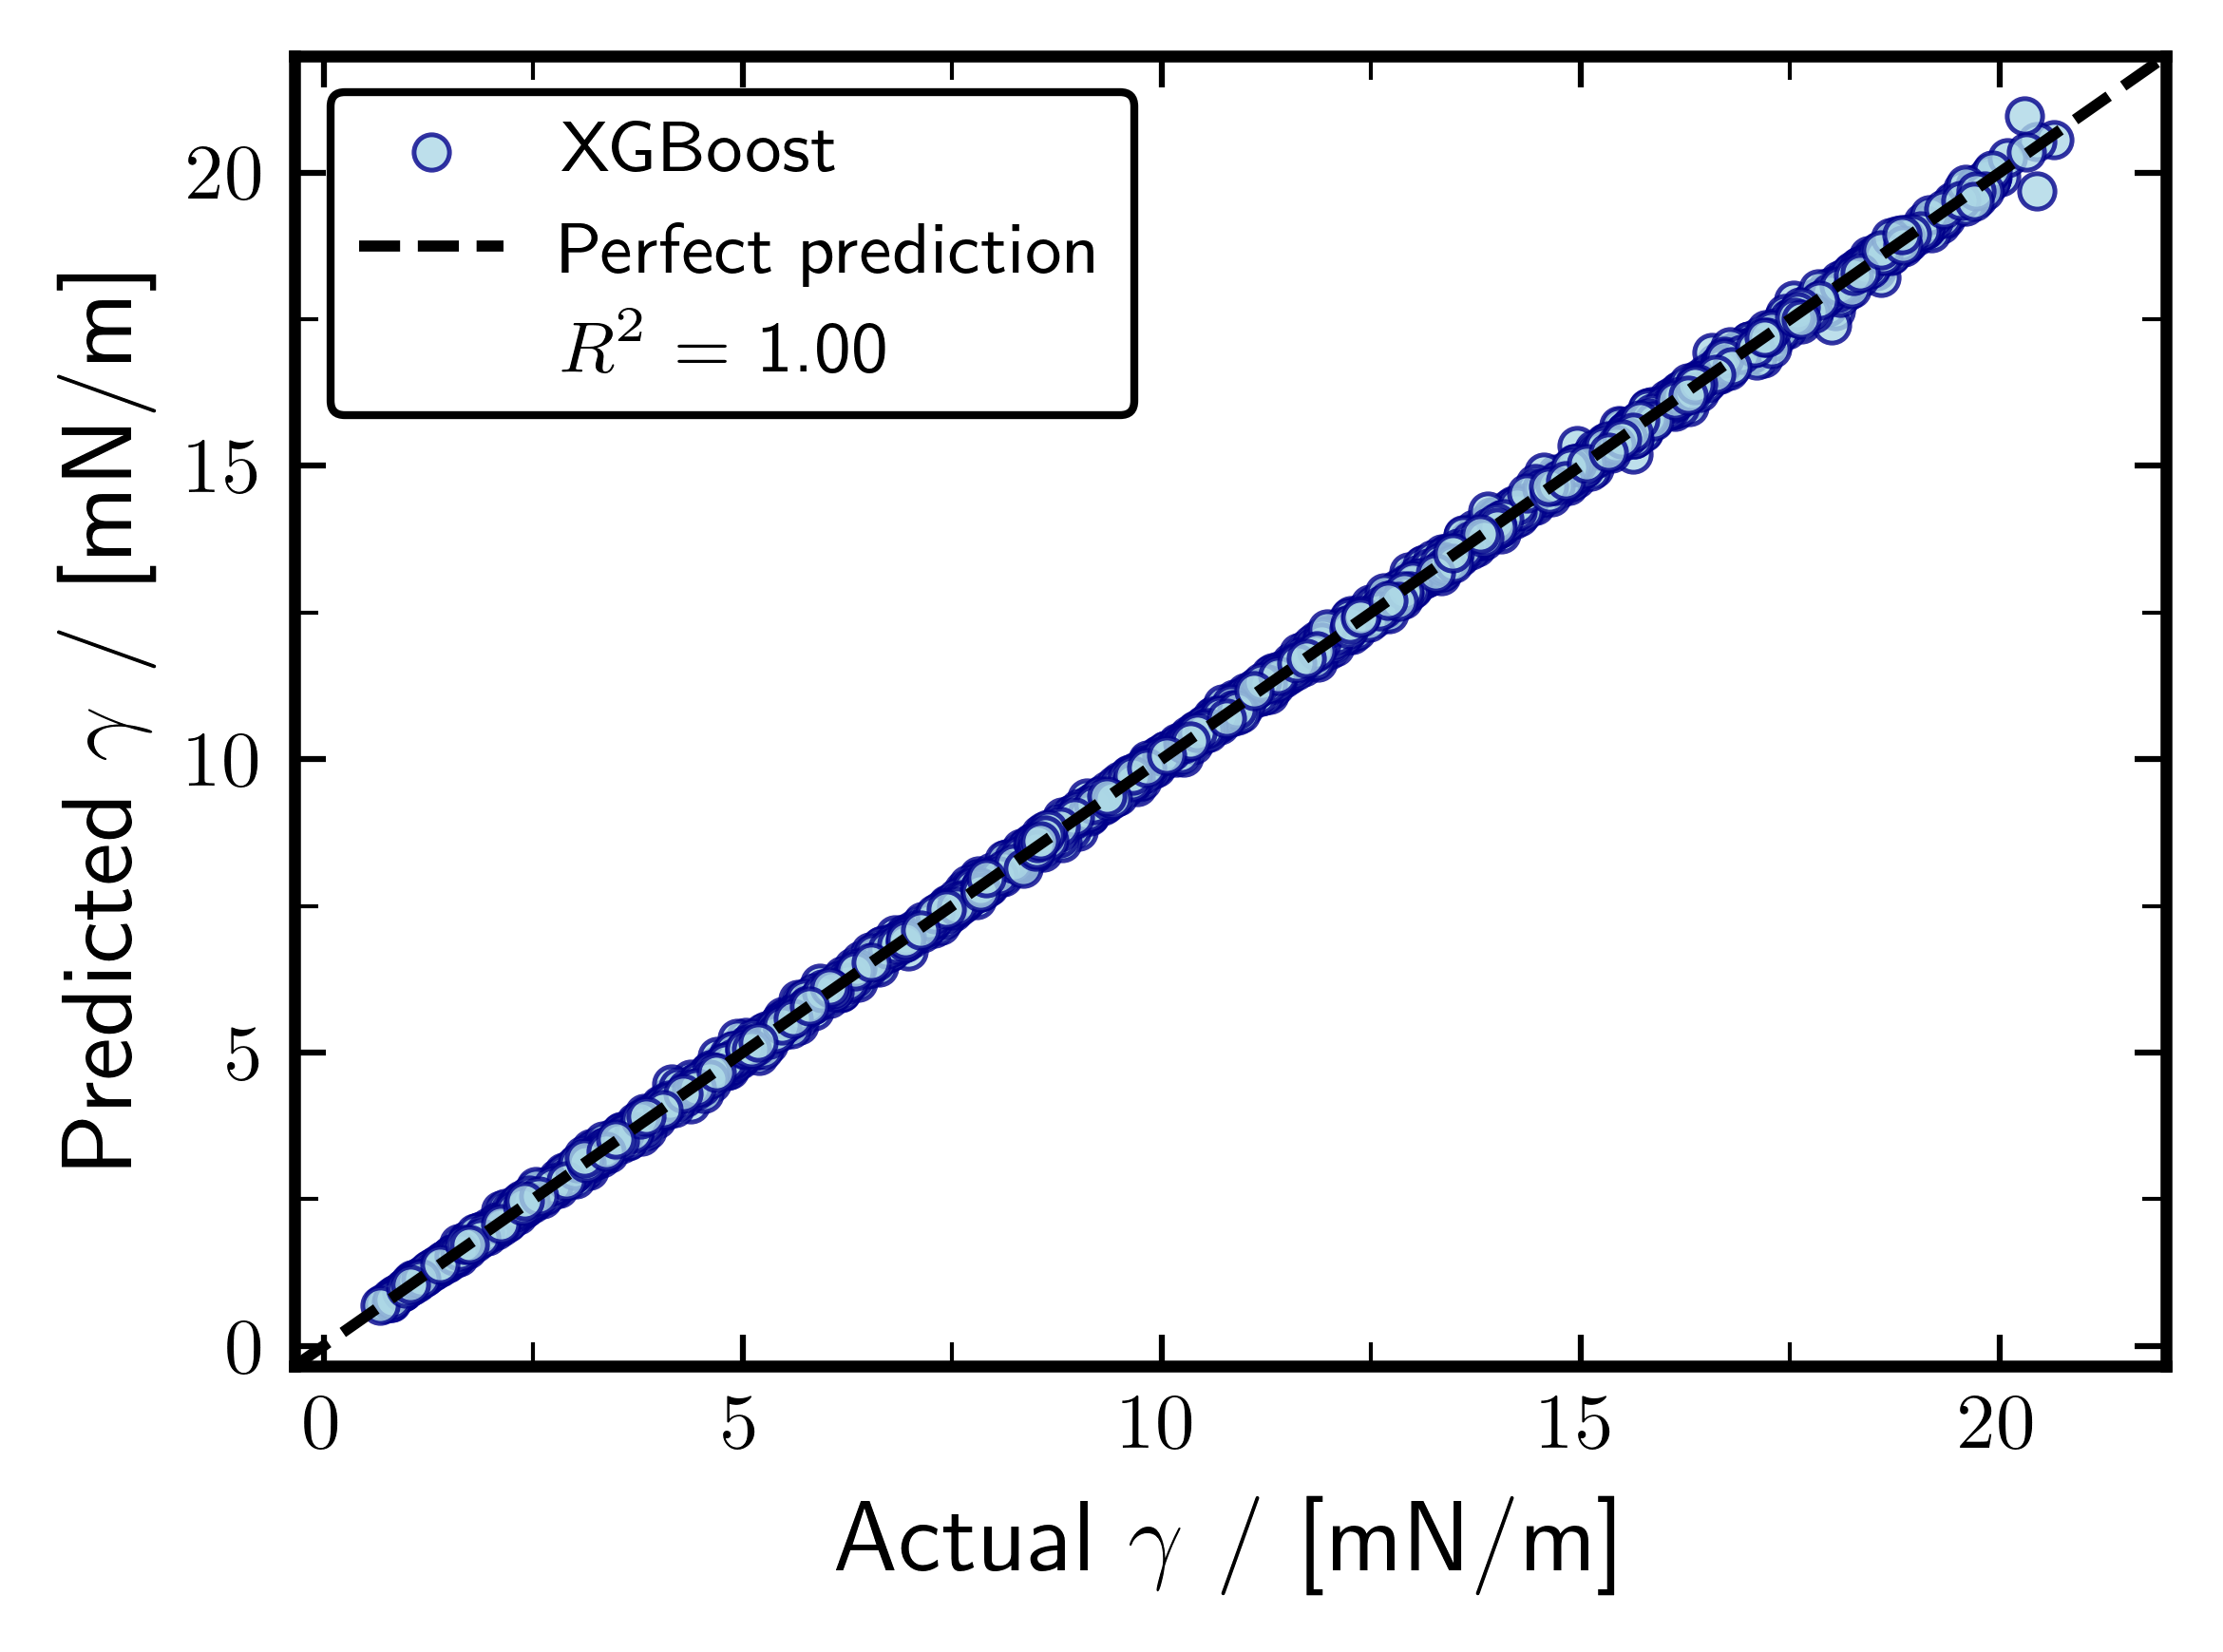

In [8]:
# Parity plot — XGBoost
fig, ax = ps.plot_init()

lims = [
    min(y_test.min(), y_test_pred.min()),
    max(y_test.max(), y_test_pred.max())
]
margin = (lims[1] - lims[0]) * 0.05
lims = [lims[0] - margin, lims[1] + margin]

ax.scatter(
    y_test, y_test_pred,
    alpha=0.8, s=20,
    facecolors="lightblue",
    edgecolors="darkblue",
    linewidths=0.6,
    label="XGBoost"
)

ax.plot(lims, lims, "k--", linewidth=1.4, label="Perfect prediction")
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_xlabel(r"Actual $\gamma$ / [mN/m]", fontsize=ps.label_fontsize * 0.9)
ax.set_ylabel(r"Predicted $\gamma$ / [mN/m]", fontsize=ps.label_fontsize * 0.9)

ps.apply_axis_style(ax)
dummy_r2 = Line2D([], [], linestyle="none", label=rf"$R^2$ = {metrics['test_r2']:.2f}")

handles, labels = ax.get_legend_handles_labels()
handles.append(dummy_r2)

ax.legend(
    handles=handles,
    fontsize=ps.label_fontsize * 0.65,
    loc="upper left",
    edgecolor="black",
    framealpha=1.0
)

ax.minorticks_on()
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis="both", which="minor", length=3)

plt.tight_layout()
ps.save_plot(fig, "XGB_gamma_parity_plot")
plt.show()

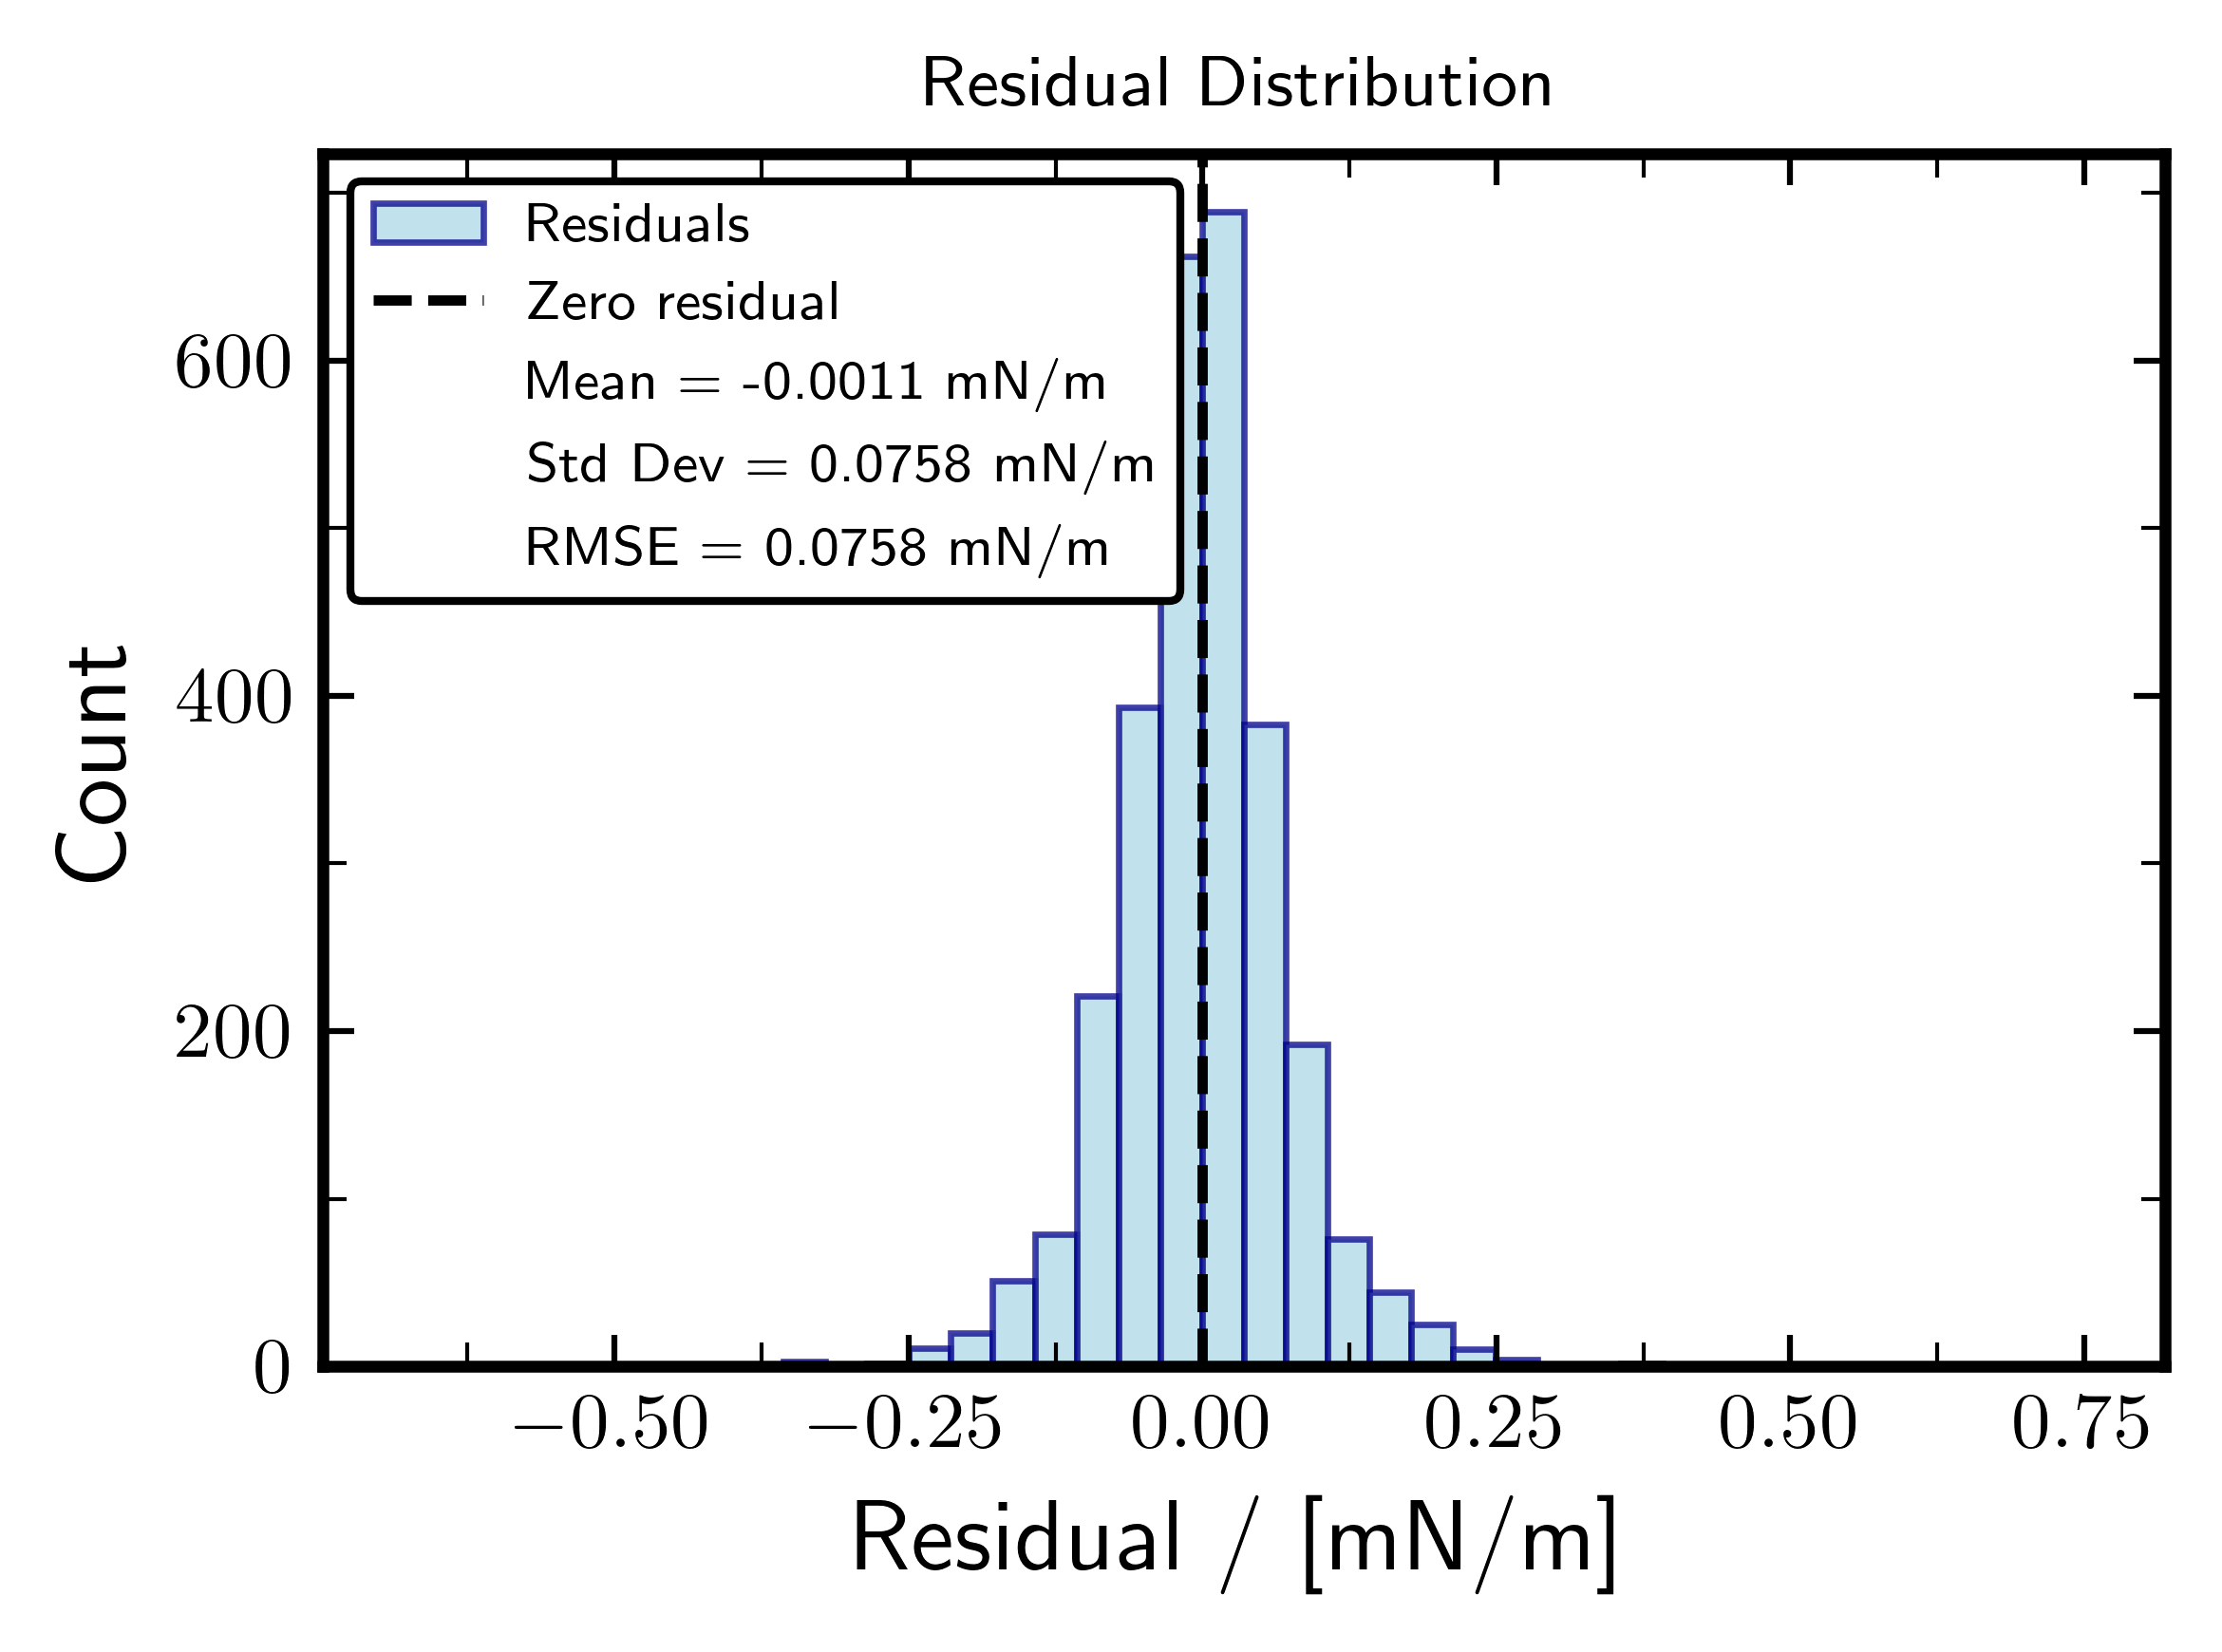

In [9]:
# Residual distribution — XGBoost
residuals = y_test.values - y_test_pred

fig, ax = ps.plot_init()

ax.hist(
    residuals,
    bins=40,
    alpha=0.75,
    color="lightblue",
    edgecolor="darkblue",
    linewidth=0.8,
    label="Residuals"
)

ax.axvline(0, color="black", linewidth=1.3, linestyle="--", label="Zero residual")

mean_resid = residuals.mean()
std_resid  = residuals.std()

ax.set_xlabel(r"Residual / [mN/m]", fontsize=ps.label_fontsize * 0.9)
ax.set_ylabel(r"Count", fontsize=ps.label_fontsize * 0.9)
ax.set_title(r"Residual Distribution", fontsize=ps.title_fontsize * 0.75, fontweight="bold")

dummy_mean = Line2D([], [], linestyle="none", label=rf"Mean = {mean_resid:.4f} mN/m")
dummy_std  = Line2D([], [], linestyle="none", label=rf"Std Dev = {std_resid:.4f} mN/m")
dummy_rmse = Line2D([], [], linestyle="none", label=rf"RMSE = {metrics['test_rmse']:.4f} mN/m")

handles, labels = ax.get_legend_handles_labels()
handles.extend([dummy_mean, dummy_std, dummy_rmse])

ps.apply_axis_style(ax)

ax.legend(
    handles=handles,
    fontsize=ps.label_fontsize * 0.5,
    loc="upper left",
    edgecolor="black",
    facecolor="white",
    framealpha=1.0
)

ax.minorticks_on()
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis="both", which="minor", length=3)

plt.tight_layout()
ps.save_plot(fig, "XGB_gamma_residual_distribution")
plt.show()

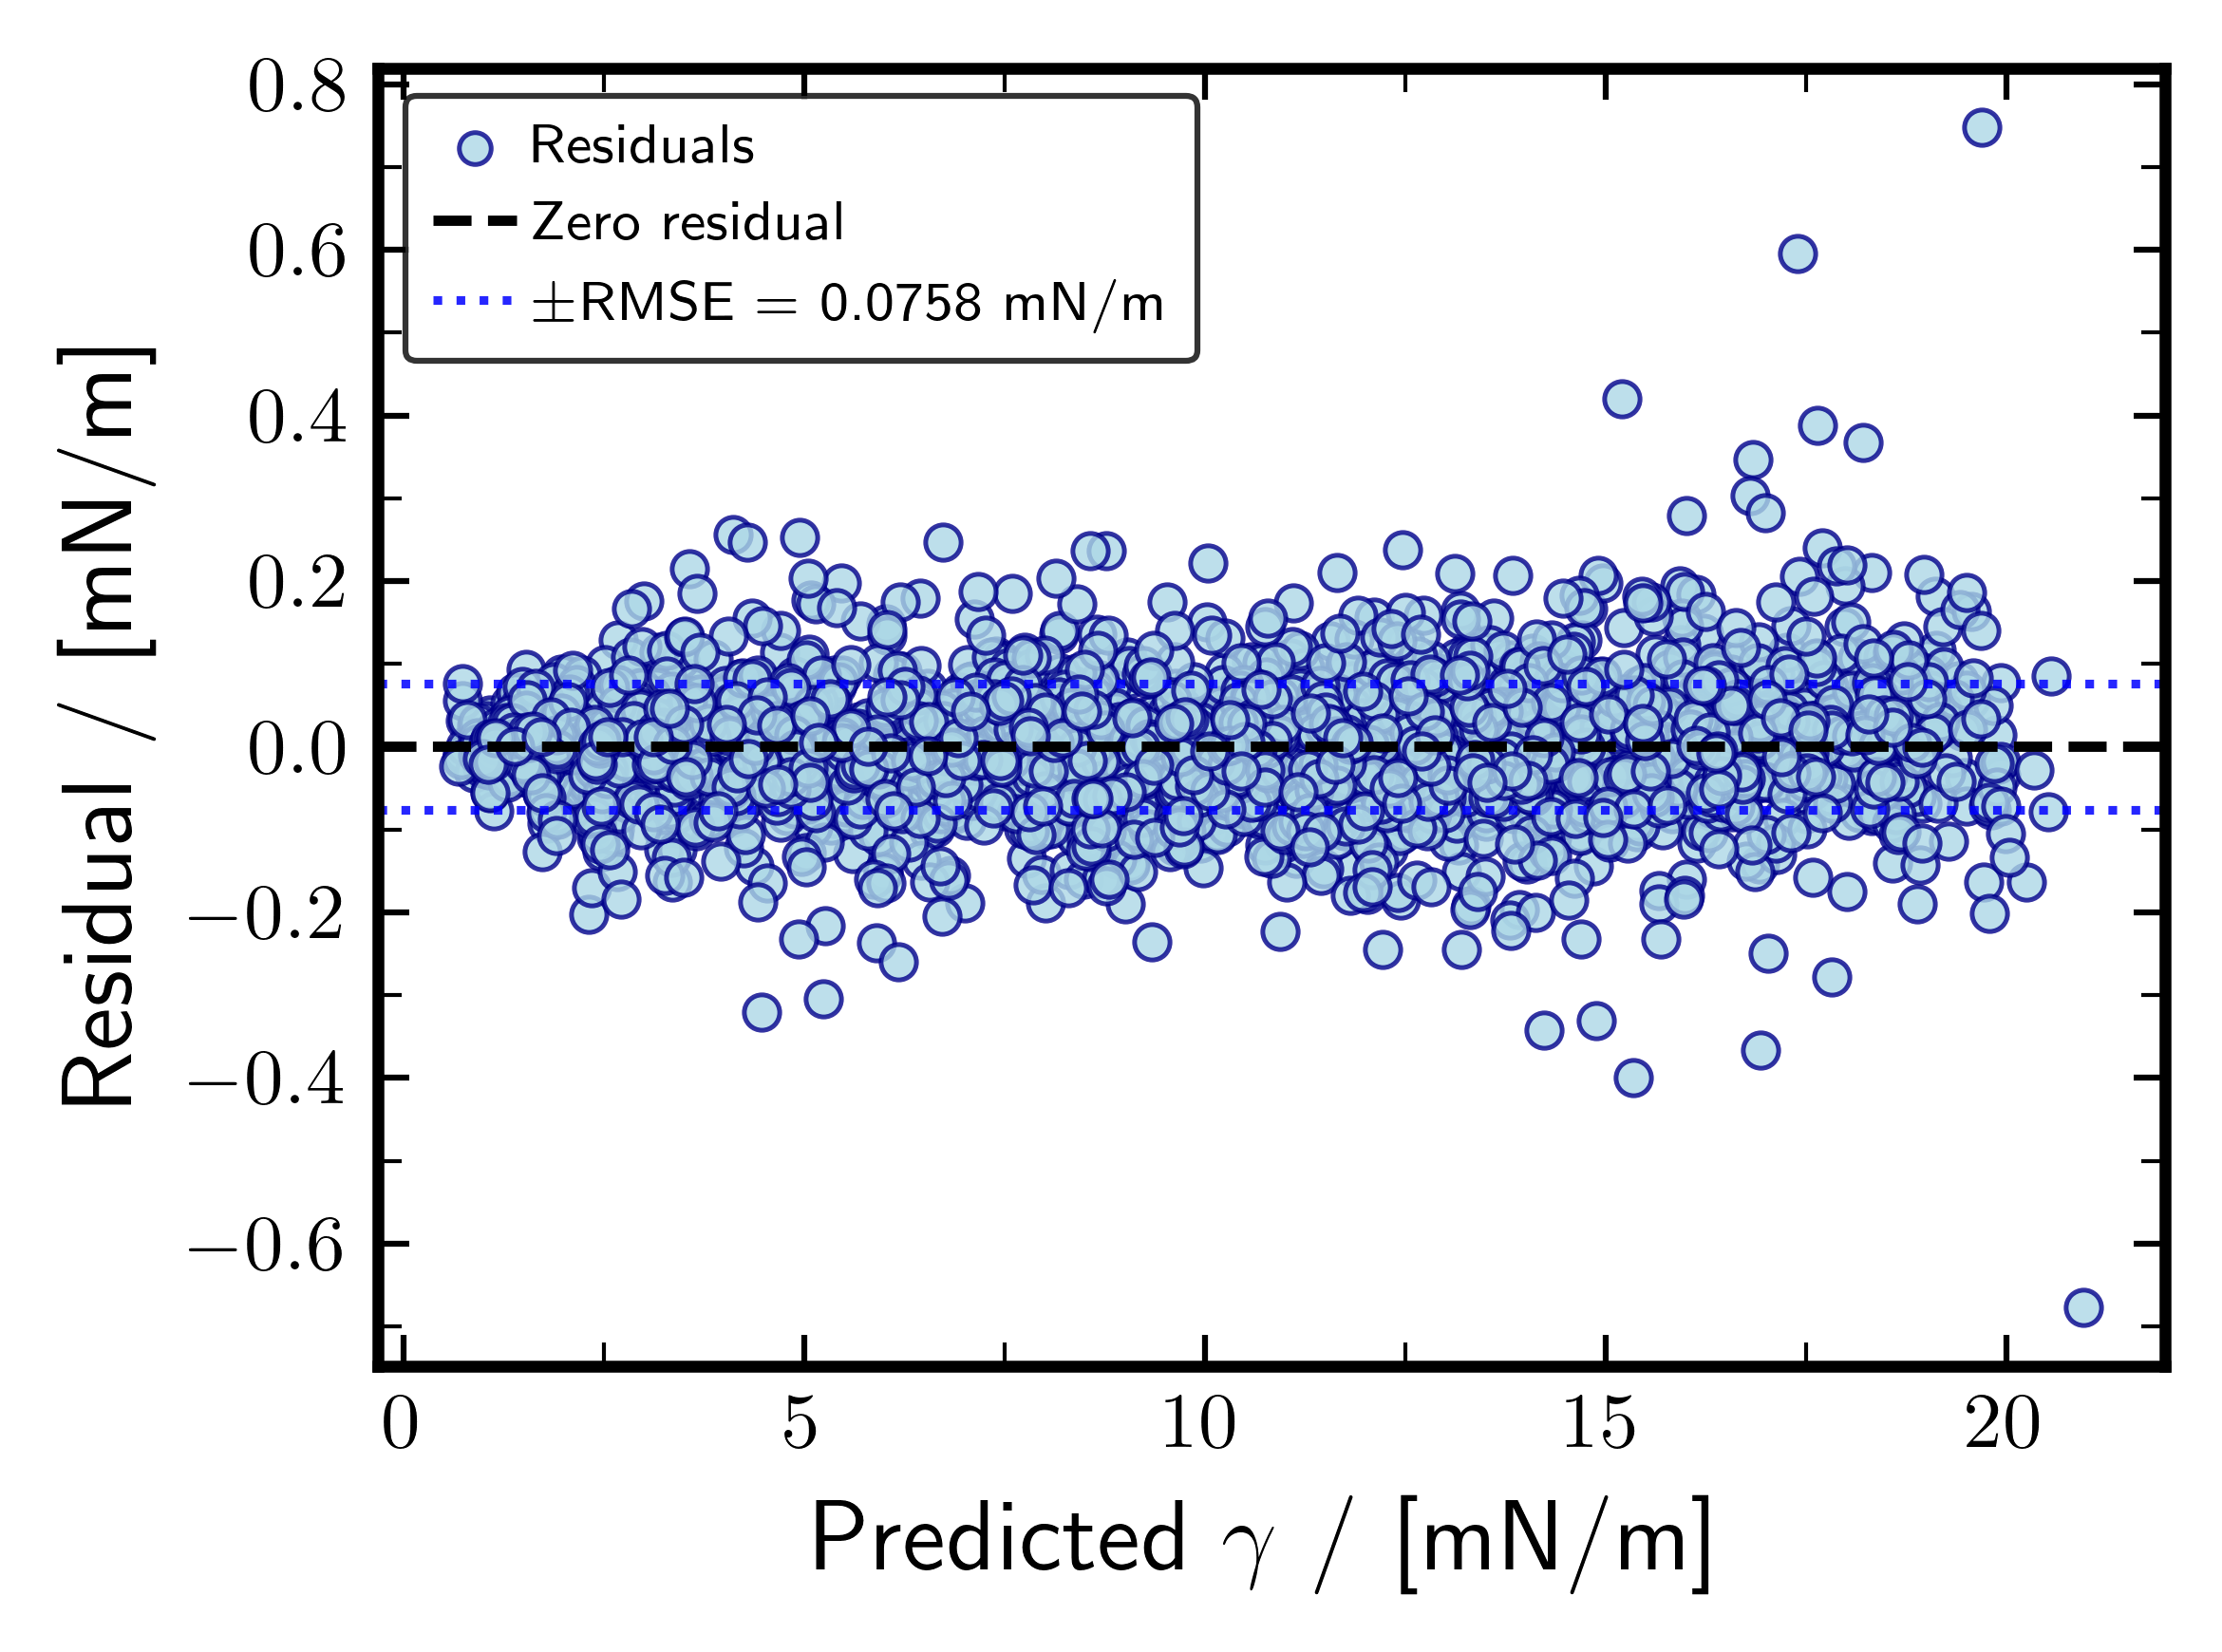

In [10]:
# Residuals vs Predicted — XGBoost
fig, ax = ps.plot_init()

ax.scatter(y_test_pred, residuals, alpha=0.8, s=20, facecolors="lightblue", edgecolors="darkblue", linewidths=0.6, label="Residuals")

ax.axhline(0, color="black", linewidth=1.3, linestyle="--", label="Zero residual")
ax.axhline(metrics['test_rmse'], color="blue", linewidth=1.1, linestyle=":", alpha=0.85, label=rf"$\pm$RMSE = {metrics['test_rmse']:.4f} mN/m")
ax.axhline(-metrics['test_rmse'], color="blue", linewidth=1.1, linestyle=":", alpha=0.85)

ax.set_xlabel(r"Predicted $\gamma$ / [mN/m]", fontsize=ps.label_fontsize * 0.9)
ax.set_ylabel(r"Residual / [mN/m]", fontsize=ps.label_fontsize * 0.9)

ps.apply_axis_style(ax)
ps.style_legend(ax, fontsize=ps.label_fontsize * 0.5, loc="upper left")

ax.minorticks_on()
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis="both", which="minor", length=3)

plt.tight_layout()
ps.save_plot(fig, "XGB_gamma_residual_vs_predicted")
plt.show()

In [11]:
# Collect and save all metrics
metrics["cv_r2_scores"]    = cv_scores.tolist()
metrics["cv_r2_mean"]      = float(cv_scores.mean())
metrics["cv_r2_std"]       = float(cv_scores.std())
metrics["model"]           = "XGBoost"
metrics["n_estimators"]    = xgb_model.n_estimators
metrics["max_depth"]       = xgb_model.max_depth
metrics["learning_rate"]   = xgb_model.learning_rate
metrics["subsample"]       = xgb_model.subsample
metrics["colsample_bytree"]= xgb_model.colsample_bytree
metrics["features"]        = features
metrics["target"]          = target
metrics["seed"]            = SEED

os.makedirs(PLOT_FOLDER, exist_ok=True)
metrics_path = os.path.join(PLOT_FOLDER, f"XGB_{target}_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2, default=str)

print(f"\nMetrics saved to: {metrics_path}")


Metrics saved to: XGBoost_OUTPUTS/XGB_gamma_metrics.json


In [12]:
notebook_end = time.perf_counter()
elapsed_minutes = (notebook_end - notebook_start) / 60
print(f"Total notebook runtime: {elapsed_minutes:.2f} minutes")

Total notebook runtime: 0.45 minutes
